# ML01: Linear Regression

## Introduction

Linear regression is used for modeling the relationship between a dependent variable $𝑦$ and one or more independent variables $x$. Given a set of data samples, the goal is to determine a linear function that best predicts $y$ based on $x$. 

## Hypothesis Function 

The hypothesis function, $h_\theta(x)$, is our predictive model. It represents a linear combination of the input features $x$, weighted by their respective coefficients $\theta$.

$$
\begin{aligned}
h_\theta(x_1, x_2, x_3, \dots, x_n) &= \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n \\
                                    &= \sum_{i=0}^{n} \theta_i x_i
\end{aligned}
$$
*(Note: we define $x_0 = 1$ here.)*

For a more compact representation, we can write this in matrix form:

$$
\boxed{h_\theta(x) = \theta^T x}
$$

where $\theta$ and $x$ are both $(n\times 1)$ column vectors.

## Error

In real-world scenarios, predictions from our hypothesis function rarely match actual values exactly due to randomness and unobserved factors. We introduce an error term $\epsilon$ to account for this discrepancy:

$$
\begin{aligned}
\mathrm{Observed\ Value} &= \mathrm{Predicted\ Value} + \mathrm{Error} \\
                 y^{(i)} &= h_\theta(x^{(i)}) + \epsilon
\end{aligned}
$$

To make meaningful inferences, we impose the following assumptions on the error term $\epsilon^{(i)}$:

1. **Independence**: The error for one data point does not influence another.
2. **Identical Distribution**: All error terms follow the same probability distribution.
3. **Normality**: The errors are normally distributed with a mean of zero and variance $\sigma^2$, i.e. $\epsilon^{(i)} \sim \mathcal{N}(0, \sigma^2)$.

Since $\epsilon^{(i)}$ is normally distributed, it follows that $y^{(i)}$ is normally distributed as well:

$$
y^{(i)} \sim \mathcal{N}(\theta^T x^{(i)}, \sigma^2)
$$

This implies that the probability density function (PDF) of $y^{(i)}$ is:

$$
f(y^{(i)}|x^{(i)};\theta) = \frac{1}{\sigma\sqrt{2\pi}} \exp \left(-\frac{(y^{(i)}-\theta^Tx^{(i)})^2}{2 \sigma^2}\right)
$$

It tells us how likely it is to observe a particular $y^{(i)}$ given $\theta$.


## Likelihood Function

We do not only have one data point $(x^{(i)}, y^{(i)})$, but many (say, $m$ of them). Since we have assumed the independence of $\epsilon$, the joint PDF of all data points is just the product of individual PDFs:

$$
f(y|X;\theta) = \prod_{i=1}^{m} {f(y^{(i)}|x^{(i)};\theta)}
$$

This is also known as the likelihood function, $L(\theta)$. By maximizing the likelihood function, we identify the $\theta$ that best explains the observed data. This method applies the principle of **Maximum Likelihood Estimation (MLE)**.

$L(\theta)$ involves a product of exponentials; it is more convenient to work with the log-likelihood function $\ell(\theta)$:

$$
\begin{aligned}
\ell(\theta) &= \ln \prod_{i=1}^{m} {f(y^{(i)}|x^{(i)};\theta)} \\
             &= \sum_{i=1}^{m} \ln {f(y^{(i)}|x^{(i)};\theta)} \\
             &= \sum_{i=1}^{m} \ln \left(\frac{1}{\sigma\sqrt{2\pi}} \exp \left(-\frac{(y^{(i)}-\theta^T x^{(i)})^2}{2 \sigma^2}\right)\right) \\
             &= m\ln \frac{1}{\sigma\sqrt{2\pi}} - \frac{1}{\sigma^2} \cdot \underbrace{\frac{1}{2} \sum_{i=1}^{m} {(y^{(i)}-\theta^T x^{(i)})^2}}_{\mathrm{defined\ as\ }J(\theta)}
\end{aligned}
$$

Ignoring the constant terms, we get:

$$
\ell(\theta) \propto -J(\theta)
$$

Thus, maximizing the $\ell(\theta)$ is equivalent to minimizing the $J(\theta)$, which is the **sum of squared errors (SSE)**.

## Normal Equation

In the previous section, we established that maximizing the $\ell(\theta)$ in MLE is equivalent to minimizing the SSE. This minimization approach is known as **Ordinary Least Squares (OLS) regression**.

We have also seen that the cost function for OLS is given by:

$$
\boxed{J(\theta) = \frac{1}{2} \sum_{i=1}^{m} {(y^{(i)}-\theta^Tx^{(i)})^2}}
$$

which can be rewritten in matrix form as:

$$
\begin{aligned}
J(\theta) &= \frac{1}{2} (y-X\theta)^T (y-X\theta) \\
          &= \frac{1}{2} (y^T-\theta^TX^T) (y - X\theta) \\
          &= \frac{1}{2} (y^Ty - y^TX\theta - \theta^TX^Ty + \theta^TX^TX\theta)
\end{aligned}
$$

Setting the gradient to zero to find the minimum:

$$
\begin{aligned}
\nabla_\theta J(\theta) &= 0 \\
                      0 &= \frac{1}{2} (0 - (y^TX)^T - X^Ty + 2X^TX\theta) \\
                        &= \frac{1}{2} (2X^TX\theta - 2X^Ty) \\
                   X^Ty &= X^TX\theta \\
                 \theta &= (X^TX)^{-1}X^Ty
\end{aligned}
$$

The final equation,

$$
\boxed{\theta = (X^TX)^{-1}X^Ty}
$$

is known as the **Normal Equation**. With this theoretical foundation in place, we can now implement it using Python.

## Implementing OLS Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
class OLSLinearRegression:
    def __init__(self, n_features: int):
        self.theta = np.zeros((n_features, 1))
        
    def fit(self, features: np.array, labels: np.array):
        assert len(features.shape) == 2 and features.shape[1] == self.theta.shape[0], "Incorrect feature shape"
        assert len(labels.shape) == 2 and labels.shape == (features.shape[0], 1), "Incorrect label shape"
        
        self.theta = np.linalg.inv(features.T @ features) @ features.T @ labels

    def __hypothesis(self, X: np.array) -> np.array:
        return X @ self.theta

    def predict(self, X: np.array) -> np.array:
        assert len(X.shape) == 2 and X.shape[1] == self.theta.shape[0], "Incorrect X shape"

        return self.__hypothesis(X)

In [3]:
# Dataset description: https://www.cs.toronto.edu/~delve/data/boston/bostonDetail.html
df_housing = pd.read_csv("datasets/boston-housing.csv")
housing_label_name = ["MEDV"]
housing_feature_names = df_housing.columns.drop(housing_label_name + ["CHAS"]).to_list()  # CHAS has a binary value, ignored

y1 = df_housing[housing_label_name].to_numpy()
X1 = df_housing[housing_feature_names].to_numpy()
X1 = np.c_[np.ones((X1.shape[0], 1)), X1]  # Let x_0 = 1 for all rows
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, train_size=0.7, random_state=42)

In [4]:
X1_train.shape, X1_test.shape, y1_train.shape, y1_test.shape

((354, 13), (152, 13), (354, 1), (152, 1))

In [5]:
print("No. of features:", X1.shape[1])
print("Train size:", X1_train.shape[0])
print("Test size:", X1_test.shape[0])

No. of features: 13
Train size: 354
Test size: 152


In [6]:
ols_lin_reg1 = OLSLinearRegression(X1_train.shape[1])
ols_lin_reg1.fit(X1_train, y1_train)

In [7]:
pd.DataFrame(ols_lin_reg1.theta, index=["(Bias)"] + housing_feature_names, columns=["Regression Coefficient"])

,Regression Coefficient
(Bias),31.428479
CRIM,-0.142477
ZN,0.038457
INDUS,0.072763
NOX,-14.900799
RM,4.146484
AGE,-0.009016
DIS,-1.418123
RAD,0.277012
TAX,-0.010257


From the results above, we can tell that RM (average number of rooms per dwelling) has the largest positive correlation with housing prices, while NOX (nitric oxides concentration (parts per 10 million)) has the largest negative correlation.

This suggests that:
- More rooms → higher home prices.
- Higher pollution levels → lower home prices.

In [8]:
y1_pred = ols_lin_reg1.predict(X1_test)
y1_pred[:10, :]  # First 10 outputs

array([[28.92343009],
       [33.78152058],
       [15.35230427],
       [25.47744011],
       [19.34401825],
       [23.22295519],
       [17.45322531],
       [14.18535528],
       [23.50357304],
       [20.72405723]])

### Metrics

#### Mean Squared Error

**Mean Squared Error (MSE)** is a common metric used to measure the average squared difference between actual and predicted values in regression models. It is very similar to the cost function $J(\theta)$ above:

$$
\boxed{\mathrm{MSE} = \frac{1}{m} \sum_{i=1}^{m} {(y^{(i)}-\theta^Tx^{(i)})^2}}
$$

MSE penalizes large errors more than small ones. A lower MSE indicates better model performance.

In [9]:
mean_squared_error(y1_test, y1_pred)

21.697160127876234

---

Let us try again with only one feature to see how the best-fit line looks like:

In [10]:
SINGLE_HOUSING_FEATURE_NAME = "LSTAT"
y1_1 = y1.copy()
X1_1 = X1[:, [0, housing_feature_names.index(SINGLE_HOUSING_FEATURE_NAME) + 1]]  # Every feature column has shifted forward by 1 due to the column of ones
X1_1.shape = (-1, 2)

In [11]:
ols_lin_reg2 = OLSLinearRegression(X1_1.shape[1])
ols_lin_reg2.fit(X1_1, y1_1)

In [12]:
ols_lin_reg2.theta

array([[34.55384088],
       [-0.95004935]])

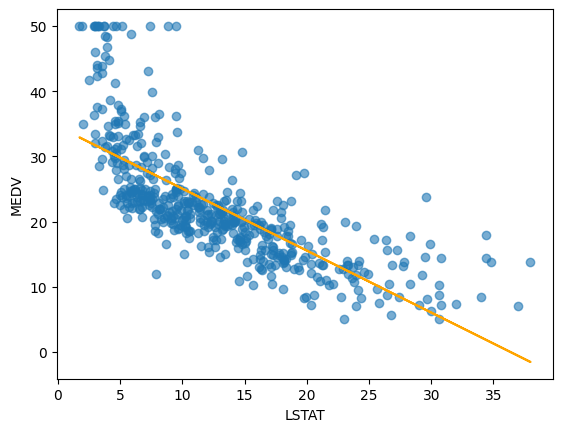

In [13]:
plt.scatter(X1_1[:, 1], y1_1, marker='o', alpha=0.6)
plt.ylabel(housing_label_name[0])
plt.xlabel(SINGLE_HOUSING_FEATURE_NAME)
plt.plot(X1_1[:, 1], ols_lin_reg2.predict(X1_1), color="Orange");

It seems that the line does not fit the data well. To address this, we extend linear regression into polynomial regression, where we introduce higher-degree terms (e.g. $x^2$, $x^3$, etc.) to allow for a curved fit.

### Polynomial Regression

We will attempt a cubic regression model.

In [14]:
from sklearn.preprocessing import PolynomialFeatures

def poly_transform(X, *, degree=3):
    return PolynomialFeatures(degree=degree).fit_transform(X)

In [15]:
poly_X1_1 = poly_transform(X1_1[:, [1]])
ols_lin_reg3 = OLSLinearRegression(poly_X1_1.shape[1])
ols_lin_reg3.fit(poly_X1_1, y1_1)

In [16]:
poly_X1_1[:5, ]  # First 5 rows

array([[  1.      ,   4.98    ,  24.8004  , 123.505992],
       [  1.      ,   9.14    ,  83.5396  , 763.551944],
       [  1.      ,   4.03    ,  16.2409  ,  65.450827],
       [  1.      ,   2.94    ,   8.6436  ,  25.412184],
       [  1.      ,   5.33    ,  28.4089  , 151.419437]])

Observe: $4.98^2 = 24.8004$, $4.98^3 = 123.505992$.

When dealing with multiple features instead of just one, `PolynomialFeatures.fit_transform` generates more terms. For example, if we have two features $x_1$ and $x_2$, a quadratic polynomial model would include not only $x_1$ and $x_2$, but also interaction terms like $x_1x_2$.

In [17]:
ols_lin_reg3.theta

array([[ 4.86496253e+01],
       [-3.86559278e+00],
       [ 1.48738477e-01],
       [-2.00386767e-03]])

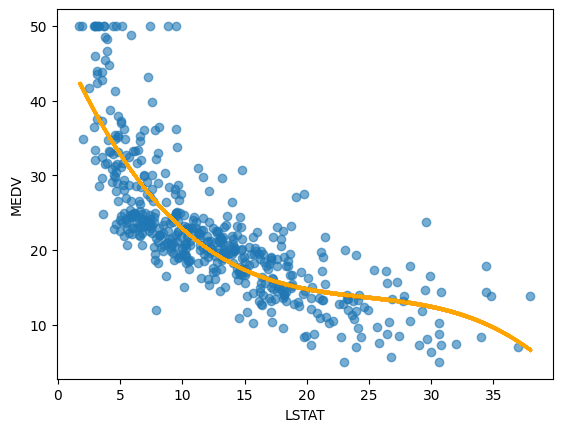

In [18]:
plt.scatter(X1_1[:, 1], y1_1, marker='o', alpha=0.6)
plt.ylabel(housing_label_name[0])
plt.xlabel(SINGLE_HOUSING_FEATURE_NAME)

def curve(X, y, *, precision=0.001):
    x_smooth = np.arange(X.min(), X.max(), precision)
    y_smooth = ols_lin_reg3.predict(poly_transform(x_smooth.reshape((-1, 1)))).flatten()
    return x_smooth, y_smooth

plt.scatter(*curve(X1_1[:, 1], ols_lin_reg3.predict(poly_X1_1)), color="Orange", marker=".", s=6);

However, a higher-degree polynomial does not always mean a better model. It may lead to overfitting, where the model captures noise instead of true patterns. Now try running the code again with `degree=15` and observe how the graph behaves.

### The Caveats

The time complexity of matrix inversion is $O(n^3)$. It is computationally expensive, especially for large datasets with many features. Additionally, if features are highly correlated, the matrix $X^TX$ may become nearly singular, leading to numerical instability.

## Batch Gradient Descent
To overcome these limitations, **Batch Gradient Descent (BGD)** provides an alternative approach. Instead of computing the exact solution, BGD iteratively compute the gradient of the loss function with respect to model parameters and take small steps <u>in the opposite direction</u>.

Mathematically:

$$
\theta \leftarrow \theta - \alpha\nabla J(\theta)
$$

where $\alpha$ is the learning rate. It determine how large is each "step", usually has the value in range 0.01 to 0.1.

### Why do we move in the opposite direction of the gradient? Or, why is the sign above negative?

Consider a simple example:

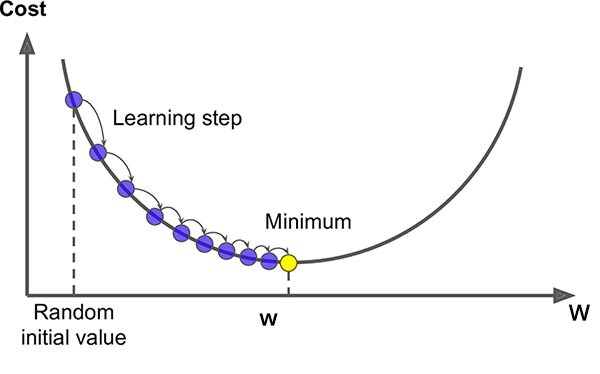 \
*(Image from the Internet)*

On the left side of the parabola, the slope (derivative) is negative. If we do $\theta \leftarrow \theta + \alpha\nabla J(\theta)$, we add a negative value, pushing $\theta$ further left, which actually increases the cost. Therefore, we should use substraction instead to make $\theta$ descends to the minimum.


### Update Rule

Let us compute $\nabla J(\theta)$ again without using matrix operations. Since:

$$
\nabla J(\theta) = \begin{bmatrix}
                   \frac{\partial J(\theta)}{\partial \theta_0} \\
                   \frac{\partial J(\theta)}{\partial \theta_1} \\
                   \vdots \\
                   \frac{\partial J(\theta)}{\partial \theta_n}
                   \end{bmatrix}
$$

we differentiate each component as follows:

$$
\begin{aligned}
\frac{\partial J(\theta)}{\partial \theta_j} &= \frac{\partial}{\partial \theta_j} \left(\frac{1}{2} \sum_{i=1}^{m} {(y^{(i)}-\theta^Tx^{(i)})^2}\right) \\
                                             &= \frac{1}{2} \sum_{i=1}^{m} {2 (y^{(i)}-\theta^Tx^{(i)}) \cdot \frac{\partial}{\partial \theta_j} (y^{(i)}-\theta^Tx^{(i)})}
\end{aligned}
$$

Note that:

$$
\begin{aligned}
                                                \theta^Tx^{(i)} &= \sum_{k=1}^{n} {\theta_k x^{(i)}_k} \\
                                                                &= \theta_0 x^{(i)}_0 + \theta_1 x^{(i)}_1 + \dots + \theta_n x^{(i)}_n \\
\frac{\partial}{\partial \theta_j} \left(\theta^Tx^{(i)}\right) &= 0 + 0 + \dots + x^{(i)}_j + \dots + 0 \\
                                                                &= x^{(i)}_j
\end{aligned}
$$

therefore:

$$
\begin{aligned}
\frac{\partial J(\theta)}{\partial \theta_j} &= -\sum_{i=1}^{m} {(y^{(i)} - \theta^Tx^{(i)})}\cdot x^{(i)}_j
\end{aligned}
$$

Thus, the gradient descent update rule is:

$$
\theta_j \leftarrow \theta_j + \alpha\sum_{i=1}^{m} {(y^{(i)} - \theta^Tx^{(i)})}\cdot x^{(i)}_j
$$
*(Be aware that it is a plus sign here—the negative gradient flips the sign.)*

Each paramter $\theta_j$ is updated separately, meaning that we compute its gradient independently before applying the update. Also, to prevent updates from being too large (when $m$ is large), we include a factor of $\frac{1}{m}$ to compute the mean gradient. Finally, we get:

$$
\boxed{\theta_j \leftarrow \theta_j + \frac{\alpha}{m} \sum_{i=1}^{m} {(y^{(i)} - \theta^Tx^{(i)})}\cdot x^{(i)}_j}
$$

### Stochastic Gradient Descent

Instead of computing the gradient using all training examples, **Stochastic Gradient Descent (SGD)** updates $\theta_j$ using only a single randomly chosen training example $(x^{(i)}, y^{(i)})$ at each iteration:

$$
\theta_j \leftarrow \theta_j + \alpha{(y^{(i)} - \theta^Tx^{(i)})}\cdot x^{(i)}_j
$$
 
This results in more frequent updates, allowing for faster convergence but with higher variance in updates.

### Mini-Batch Gradient Descent

A compromise between BGD and SGD, **Mini-Batch Gradient Descent (MBGD)** computes the gradient over a small subset (mini-batch) of randomly chosen training examples. The update rule remains the same, but the sum is computed over the mini-batch:

$$
\theta_j \leftarrow \theta_j + \frac{\alpha}{b} \sum_{i\in\mathrm{batch}} {(y^{(i)} - \theta^Tx^{(i)})}\cdot x^{(i)}_j
$$

where $b$ is the mini-batch size.

## Implementing BGD Regression

In [19]:
class BGDLinearRegression:
    def __init__(self, n_features: int):
        self.theta = np.zeros((n_features, 1))
        self.theta_history = [np.copy(self.theta)]
        self.mse_history = []

    def __gradient_descent(self, X: np.array, y: np.array, alpha: float):
        m = X.shape[0]
        # for j in range(self.theta.shape[0]):
        #     self.theta[j, 0] += (alpha / features.shape[0] * (labels - self.__hypothesis(features)).T @ features[:, [j]])[0, 0]
        self.theta += (alpha / m * (y - self.__hypothesis(X)).T @ X).T
        self.theta_history.append(np.copy(self.theta))
        
    def fit(self, features: np.array, labels: np.array, *, n_iter=1000, alpha=0.01):
        assert len(features.shape) == 2 and features.shape[1] == self.theta.shape[0], "Incorrect feature shape"
        assert len(labels.shape) == 2 and labels.shape == (features.shape[0], 1), "Incorrect label shape"

        self.mse_history.append(mean_squared_error(labels, self.__hypothesis(features)))
        for _ in range(n_iter):
            self.__gradient_descent(features, labels, alpha)
            self.mse_history.append(mean_squared_error(labels, self.__hypothesis(features)))

    def __hypothesis(self, X: np.array) -> np.array:
        return X @ self.theta

    def predict(self, X: np.array) -> np.array:
        assert len(X.shape) == 2 and X.shape[1] == self.theta.shape[0], "Incorrect X shape"

        return self.__hypothesis(X)

In [20]:
TRUE_THETA = np.array([[4], [3]])

def gen_data(size):
    np.random.seed(42)
    X = np.random.rand(size, 1)  # In range [0, 1)
    X = np.c_[np.ones((X.shape[0], 1)), X]  # Let x_0 = 1 for all rows
    y = X @ TRUE_THETA + np.random.randn(size, 1)
    return X, y

X2_train, y2_train = gen_data(1000)
bgd_lin_reg1 = BGDLinearRegression(X2_train.shape[1])
bgd_lin_reg1.fit(X2_train, y2_train)

In [21]:
bgd_lin_reg1.theta

array([[4.31062406],
       [2.58687505]])

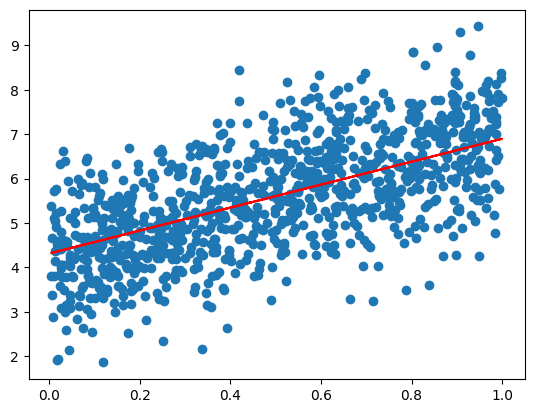

In [22]:
plt.scatter(X2_train[:, 1], y2_train)
plt.plot(X2_train[:, 1], bgd_lin_reg1.predict(X2_train), color='red');

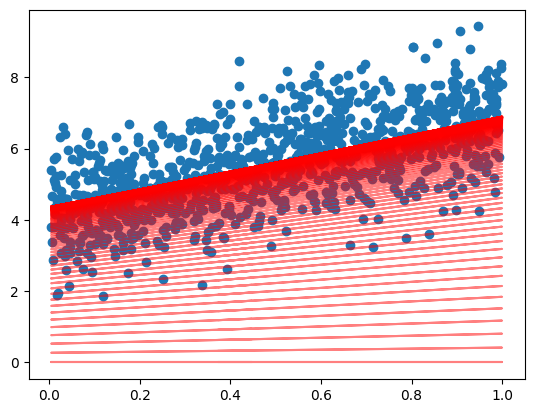

In [23]:
plt.scatter(X2_train[:, 1], y2_train)
for old_theta in bgd_lin_reg1.theta_history[::5]:  # Plot for every 5th in the history
    bgd_lin_reg1.theta = old_theta
    plt.plot(X2_train[:, 1], bgd_lin_reg1.predict(X2_train), color='red', alpha=0.5);

In [24]:
X2_test, y2_test = gen_data(10)
bgd_lin_reg1.predict(X2_test)

array([[5.27951255],
       [6.77000318],
       [6.20420093],
       [5.85927876],
       [4.71422479],
       [4.7141624 ],
       [4.46087911],
       [6.55131352],
       [5.86563349],
       [6.14231935]])

In [25]:
mean_squared_error(y2_test, bgd_lin_reg1.predict(X2_test))

1.1502133553324319

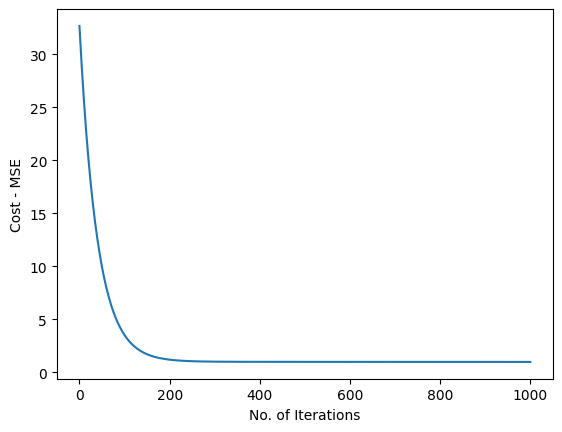

In [26]:
plt.plot(range(len(bgd_lin_reg1.mse_history)), bgd_lin_reg1.mse_history)
plt.xlabel("No. of Iterations")
plt.ylabel("Cost - MSE");

## Using Scikit-Learn

In practice, we will never need to implement the methods ourselves. Let us see how we can utilise the `sklearn` library to do linear regression.

In [27]:
from sklearn.linear_model import LinearRegression, SGDRegressor

In [28]:
df_insurance = pd.read_csv("datasets/insurance.csv")
insurance_label_name = ["charges"]
insurance_single_feature_name = ["age"]

X3_train, X3_test, y3_train, y3_test = train_test_split(df_insurance[insurance_single_feature_name], df_insurance[insurance_label_name], train_size=0.7, random_state=42)

In [29]:
sk_lin_reg1 = LinearRegression()
sk_lin_reg1.fit(X3_train, y3_train)

LinearRegression()

`LinearRegression` uses OLS method. We will use `SGDRegressor` for GD method in the next section.

In [30]:
y3_pred = sk_lin_reg1.predict(X3_test)
sk_lin_reg1.coef_, sk_lin_reg1.intercept_

(array([[247.59955092]]), array([3673.83687533]))

In [31]:
mean_squared_error(y3_test, y3_pred)

131661435.9503076

### Handling Categorical Features

To include categorical features in a model, we need to convert them into numerical representations. The three common techniques for encoding categorical variables are:

1. **Binary Encoding**: If a feature has only two categories (a binary variable), we can represent them using 0 and 1.
2. **Ordinal Encoding**: If the categories have a meaningful order (e.g., High School, Bachelor's, Master's, PhD), we can map them to numerical values (e.g., 1, 2, 3, 4) while preserving their ranking.
3. **One-Hot Encoding**: For features with more than two categories, we create separate columns for each category, assigning 1 if a sample belongs to that category and 0 otherwise. \
   Consider a categorical feature like "City" with three possible values: New York, Los Angeles, and Chicago. Instead of representing the city names as text, we create three new columns—one for each city. If a row belongs to New York, the "New York" column is set to 1 while the others are 0.

In [32]:
# Binary encoding - smoker, sex
df_insurance1 = df_insurance.copy()
df_insurance1["smoker"] = df_insurance1.smoker.map({'no': 0, 'yes': 1})
df_insurance1['sex'] = df_insurance1.sex.map({'female': 0, 'male': 1})

In [33]:
# One-Hot encoding - region
from sklearn.preprocessing import OneHotEncoder

one_hot_enc = OneHotEncoder()
one_hot_enc.fit(df_insurance1[['region']])
one_hot_enc.categories_[0]

array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)

In [34]:
df_insurance1[one_hot_enc.categories_[0]] = one_hot_enc.transform(df_insurance1[['region']]).toarray()
df_insurance1.drop("region", axis=1, inplace=True)
df_insurance1[one_hot_enc.categories_[0]]

,northeast,northwest,southeast,southwest
0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0
...,...,...,...,...
1333,0.0,1.0,0.0,0.0
1334,1.0,0.0,0.0,0.0
1335,0.0,0.0,1.0,0.0
1336,0.0,0.0,0.0,1.0


In [35]:
insurance_feature_names = df_insurance1.columns.drop(insurance_label_name).to_list()

X3_1_train, X3_1_test, y3_1_train, y3_1_test = train_test_split(df_insurance1[insurance_feature_names], df_insurance1[insurance_label_name], train_size=0.7, random_state=42)

### Standadization

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X3_1_train_scaled = scaler.fit_transform(X3_1_train)
X3_1_test_scaled = scaler.transform(X3_1_test)

`StandardScaler` standardizes features by removing the mean and scaling to unit variance. It transforms the data so that each feature has mean = 0 and standard deviation = 1.

$$
x' = \frac{x-\mu}{\sigma}
$$

Gradient-based methods work best when features have similar scales. If one feature has values in thousands and another is in decimals, gradient updates become unstable. A feature with a larger range of inputs may disproportionately affect the loss and dominate the optimization process. Therefore, standardization is important to ensure all features contribute equally.

You may try to run without `StandardScaler`, you will see the MSE raises from $10^7$ to $10^9$.

In [37]:
sk_lin_reg2 = SGDRegressor()
sk_lin_reg2.fit(X3_1_train_scaled, y3_1_train)

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGDRegressor()

`SGDRegressor` uses SGD method by default i.e. only one training sample per update. However, we may adjust the `batch_size` parameter to use mini-batches.

In [38]:
y3_1_pred = sk_lin_reg2.predict(X3_1_test_scaled)
sk_lin_reg2.coef_, sk_lin_reg2.intercept_

(array([3639.1352836 ,   43.19323248, 2089.61069476,  477.68240729,
        9650.40640973,  313.55733416,  -20.25255166, -138.64484321,
        -158.7599114 ]),
 array([13421.04193802]))

In [39]:
mean_squared_error(y3_1_test, y3_1_pred)

33810351.713059254

## Key Takeaways

- Linear regression models the relationship between features and the target variable using a straight line.
- OLS minimizes the SSE to find the best-fit coefficients. It provides a direct solution but becomes computationally expensive for large datasets. (`sklearn.linear_model.LinearRegression`)
- GD optimizes the model by iteratively updating coefficients. (`sklearn.linear_model.SGDRegressor`)
- Feature Standardization improves optimization stability by ensuring features have a consistent scale. (`sklearn.preprocessing.StandardScaler`)
- Categorical features can be converted into numerical values using binary encoding, one-hot encoding, or ordinal encoding. (`sklearn.preprocessing.OneHotEncoder`)
- MSE is a common matric to evaluate model performance. It measures the average squared difference between actual and predicted values. (`sklearn.metrics.mean_squared_error`)
- Polynomial Regression extends linear regression by incorporating polynomial features, allowing the model to capture non-linearity. (`sklearn.preprocessing.PolynomialFeatures`)